In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from modules.detection import (
    detect_extreme_deviation_users,
    detect_cusum_users,
    combine_flagged_users,
    detection_rate,
    false_positive_rate
)

DATA_DIR = Path("data")
RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

rt_clean = pd.read_csv(DATA_DIR / "rt_clean.csv")

print("Clean dataset shape:", rt_clean.shape)

Clean dataset shape: (339, 5825)


In [2]:
def inject_malicious_users(rating_matrix, attack_rate, seed=42):
    """
    Inject synthetic malicious users into a clean rating matrix.

    attack_rate: 0.10, 0.20, or 0.30
    """
    np.random.seed(seed)

    malicious_matrix = rating_matrix.copy()

    num_users = malicious_matrix.shape[0]
    num_malicious_users = int(np.ceil(num_users * attack_rate))

    malicious_user_indices = np.random.choice(
        malicious_matrix.index,
        size=num_malicious_users,
        replace=False
    )

    attack_records = []

    for user_id in malicious_user_indices:
        rated_items = malicious_matrix.loc[user_id].notna()

        attack_type = np.random.choice(["high", "low"])

        if attack_type == "high":
            malicious_matrix.loc[user_id, rated_items] = 1.0
        else:
            malicious_matrix.loc[user_id, rated_items] = 0.0

        attack_records.append({
            "user_id": user_id,
            "is_malicious": 1,
            "attack_type": attack_type,
            "attack_rate": attack_rate
        })

    labels = pd.DataFrame(attack_records)

    return malicious_matrix, labels

In [3]:
attack_rates = [0.10, 0.20, 0.30]

all_detection_results = []

for attack_rate in attack_rates:
    percent_label = int(attack_rate * 100)

    print(f"\nRunning {percent_label}% malicious-user experiment...")

    rt_malicious, labels = inject_malicious_users(
        rating_matrix=rt_clean,
        attack_rate=attack_rate,
        seed=42
    )

    # Save malicious dataset and labels
    malicious_file = DATA_DIR / f"rt_malicious_{percent_label}.csv"
    labels_file = DATA_DIR / f"malicious_users_{percent_label}_percent.csv"

    rt_malicious.to_csv(malicious_file, index=False)
    labels.to_csv(labels_file, index=False)

    # Detection method 1: extreme deviation
    extreme_users = detect_extreme_deviation_users(
        rating_matrix=rt_malicious,
        baseline_matrix=rt_clean,
        deviation_threshold=0.35,
        ratio_threshold=0.60,
        min_ratings=5
    )

    # Detection method 2: CUSUM
    cusum_users = detect_cusum_users(
        rating_matrix=rt_malicious,
        baseline_matrix=rt_clean,
        drift=0.02,
        threshold=5.00,
        min_ratings=5
    )

    combined_flagged_users = combine_flagged_users(
        extreme_users,
        cusum_users
    )

    true_malicious_users = labels["user_id"].tolist()

    dr = detection_rate(
        true_malicious_users=true_malicious_users,
        flagged_users=combined_flagged_users
    )

    fpr = false_positive_rate(
        true_malicious_users=true_malicious_users,
        flagged_users=combined_flagged_users,
        total_users=rt_clean.shape[0]
    )

    result = {
        "attack_rate": attack_rate,
        "attack_percentage": percent_label,
        "total_users": rt_clean.shape[0],
        "known_malicious_users": len(true_malicious_users),
        "extreme_deviation_flagged_users": len(extreme_users),
        "cusum_flagged_users": len(cusum_users),
        "total_combined_flagged_users": len(combined_flagged_users),
        "detection_rate": dr,
        "false_positive_rate": fpr
    }

    all_detection_results.append(result)

    flagged_df = pd.DataFrame({
        "user_id": sorted(list(combined_flagged_users)),
        "flagged": 1,
        "attack_percentage": percent_label
    })

    flagged_df.to_csv(
        RESULTS_DIR / f"flagged_users_{percent_label}_percent.csv",
        index=False
    )

    print(f"{percent_label}% experiment complete.")
    print("Known malicious users:", len(true_malicious_users))
    print("Total flagged users:", len(combined_flagged_users))
    print(f"Detection Rate: {dr:.4f}")
    print(f"False Positive Rate: {fpr:.4f}")


Running 10% malicious-user experiment...
10% experiment complete.
Known malicious users: 34
Total flagged users: 34
Detection Rate: 1.0000
False Positive Rate: 0.0000

Running 20% malicious-user experiment...
20% experiment complete.
Known malicious users: 68
Total flagged users: 68
Detection Rate: 1.0000
False Positive Rate: 0.0000

Running 30% malicious-user experiment...
30% experiment complete.
Known malicious users: 102
Total flagged users: 102
Detection Rate: 1.0000
False Positive Rate: 0.0000


In [4]:
multi_attack_results_df = pd.DataFrame(all_detection_results)

multi_attack_results_df.to_csv(
    RESULTS_DIR / "multi_attack_detection_metrics.csv",
    index=False
)

multi_attack_results_df

,attack_rate,attack_percentage,total_users,known_malicious_users,extreme_deviation_flagged_users,cusum_flagged_users,total_combined_flagged_users,detection_rate,false_positive_rate
0,0.1,10,339,34,19,34,34,1.0,0.0
1,0.2,20,339,68,39,68,68,1.0,0.0
2,0.3,30,339,102,56,102,102,1.0,0.0


In [5]:
thesis_multi_attack_table = multi_attack_results_df.copy()

thesis_multi_attack_table["detection_rate_percent"] = thesis_multi_attack_table["detection_rate"] * 100
thesis_multi_attack_table["false_positive_rate_percent"] = thesis_multi_attack_table["false_positive_rate"] * 100

thesis_multi_attack_table = thesis_multi_attack_table[
    [
        "attack_percentage",
        "known_malicious_users",
        "total_combined_flagged_users",
        "detection_rate_percent",
        "false_positive_rate_percent"
    ]
]

thesis_multi_attack_table.to_csv(
    RESULTS_DIR / "thesis_multi_attack_detection_table.csv",
    index=False
)

thesis_multi_attack_table

,attack_percentage,known_malicious_users,total_combined_flagged_users,detection_rate_percent,false_positive_rate_percent
0,10,34,34,100.0,0.0
1,20,68,68,100.0,0.0
2,30,102,102,100.0,0.0


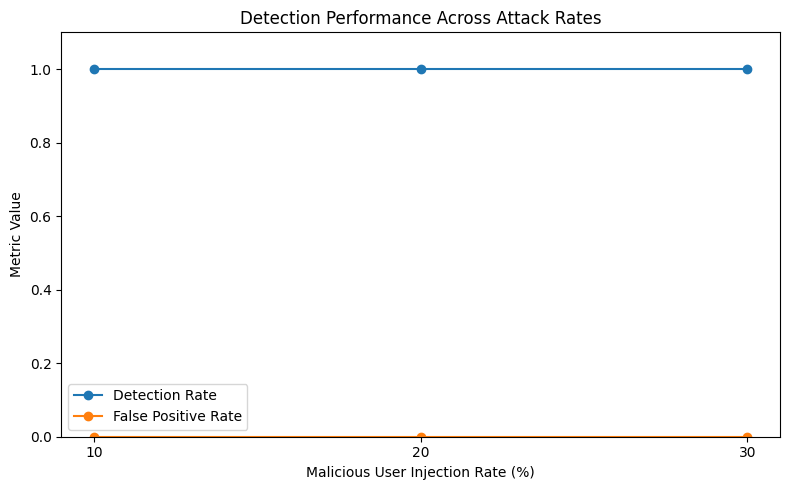

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    multi_attack_results_df["attack_percentage"],
    multi_attack_results_df["detection_rate"],
    marker="o",
    label="Detection Rate"
)

plt.plot(
    multi_attack_results_df["attack_percentage"],
    multi_attack_results_df["false_positive_rate"],
    marker="o",
    label="False Positive Rate"
)

plt.title("Detection Performance Across Attack Rates")
plt.xlabel("Malicious User Injection Rate (%)")
plt.ylabel("Metric Value")
plt.ylim(0, 1.1)
plt.xticks([10, 20, 30])
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "figure_multi_attack_detection_performance.png",
    dpi=300
)

plt.show()

In [7]:
paragraph = """
The malicious-user detection experiment was extended to three controlled synthetic attack rates: 10%, 20% and 30% of the total user population. For each attack rate, malicious users were injected by replacing their existing ratings with extreme high or low values, while the ground-truth malicious-user labels were stored separately for evaluation. The combined detection module used deviation-based filtering and CUSUM-based behavioural monitoring to identify suspicious users. The resulting comparison table reports the number of injected malicious users, the number of flagged users, detection rate and false positive rate for each attack setting. These results provide a clearer evaluation of the RDTMF detection layer under increasing attack density and directly support the experimental design described in the thesis.
"""

with open(RESULTS_DIR / "multi_attack_detection_paragraph.txt", "w") as f:
    f.write(paragraph)

print(paragraph)


The malicious-user detection experiment was extended to three controlled synthetic attack rates: 10%, 20% and 30% of the total user population. For each attack rate, malicious users were injected by replacing their existing ratings with extreme high or low values, while the ground-truth malicious-user labels were stored separately for evaluation. The combined detection module used deviation-based filtering and CUSUM-based behavioural monitoring to identify suspicious users. The resulting comparison table reports the number of injected malicious users, the number of flagged users, detection rate and false positive rate for each attack setting. These results provide a clearer evaluation of the RDTMF detection layer under increasing attack density and directly support the experimental design described in the thesis.

